### Exercise 3 (Hard)

Look at the [WikiArt dataset](https://github.com/cs-chan/ArtGAN/blob/master/WikiArt%20Dataset/README.md). Pick a task of your choice among artist, genre, and style classification. Design, implement, and evaluate a model for this task. Consider starting by reusing the simple model we devised above, and expand from it using more advanced architectures. You can use pre-trained models or implement your own approach from scratch, or both.

In [1]:
# IMPORTS #

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image
import os, random
import pandas as pd
from torchmetrics.classification import MulticlassF1Score, ConfusionMatrix
from torchinfo import summary
from datetime import datetime
import numpy as np
import statistics as stat
import json

## Imports for plotting
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.colors import to_rgba
import seaborn as sns
sns.set_theme('notebook', style='whitegrid')

from typing import Optional, Literal


## Progress bar
from tqdm.notebook import tqdm

import torch
print(torch.__version__)


RANDOM_SEED = 420
torch.manual_seed(RANDOM_SEED) # Setting the seed

if torch.cuda.is_available():
    device = torch.device("cuda")  # setting device agnostic device
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

device

2.4.1+cu124


device(type='cuda')

#### Preprocessing  

In [2]:
#Data exploration

train_df = pd.read_csv('./data/wikiart/wikiart_csv/style_train.csv', header=None)
train_df.columns = ["train_paths", "train_labels"]
train_count = train_df["train_labels"].value_counts().values
train_mean = sum(train_count)/len(train_count)
train_median = stat.median(train_count)

val_df = pd.read_csv('./data/wikiart/wikiart_csv/style_val.csv', header=None)
val_df.columns = ["val_paths", "val_labels"]
val_count = val_df["val_labels"].value_counts().values
val_mean = sum(val_count)/len(val_count)
val_median = stat.median(val_count)


print(train_count)
print(train_mean, train_median)
print(val_count)
print(val_mean, val_median)

[9142 7514 4914 4716 4515 3170 3034 2968 1948 1787 1684 1565 1463 1131
 1039  974  941  936  896  817  654  360  337  220  152   77   69]
2111.962962962963 1131
[3918 3219 2105 2020 1935 1358 1300 1272  834  765  721  670  626  484
  444  417  402  401  383  350  280  153  144   94   64   33   29]
904.4814814814815 484


In [3]:

def get_RGB_stats(dataset, device="cpu"):
    channel_sums = torch.zeros(3, device=device)
    squared_sums = torch.zeros(3, device=device)
    total_pixels = 0
    
    dataloader = DataLoader(dataset, batch_size=1)  # Assuming batch size of 1 for simplicity
    
    for image, _ in tqdm(dataloader, desc="Computing RGB statistics"):
        image = image.to(device)  # Ensure the image is moved to the specified device
        _, channels, height, width = image.shape  # Extract dimensions
        total_pixels += channels * height * width  # Total pixel count
        
        # Summing pixel values and squared values channel-wise
        for i in range(3):  # R, G, B channels
            channel = image[:, i, :, :]  # Select the i-th channel
            channel_sums[i] += channel.sum()
            squared_sums[i] += (channel ** 2).sum()
    
    # Compute means
    means = channel_sums / total_pixels
    
    # Compute standard deviations
    stds = torch.sqrt(squared_sums / total_pixels - means ** 2)
    
    return means.cpu().numpy(), stds.cpu().numpy()


In [4]:
class WikiArtImageDataset(Dataset):
    def __init__(self, classes: list, data_df: pd.DataFrame, img_dir: str, transform=None, fraction: float = 1.0):
        self.classes = classes
        self.data = data_df
        self.data.columns = ["Paths", "Labels"]
        if fraction < 1.0:
            self.data = self.sample_data(fraction=fraction)
        elif fraction != 1.0:
            raise TypeError("Fractions have to be between 0 and 1")
        self.img_dir = img_dir
        self.transform = transform

        # ENCODING STRINGS IN DICT 
        self.enc = {name: idx for idx, name in enumerate(self.classes)}
        # Create a reverse mapping for integer labels back to string labels
        self.dec = {idx: label for label, idx in self.enc.items()}
                                                                         
    def __len__(self):
        return len(self.data)

    # Applied each time batches are returned by DataLoader, executing all the "preprocessing"
    def __getitem__(self, index):
        img_path = os.path.join(self.img_dir, self.data.iloc[index, 0])
        image = Image.open(img_path).convert("RGB")
        label = self.data.iloc[index, 1]
        # Convert string label to integer
        if self.transform:
            image = self.transform(image)

        return image, label 
    
    # Function to adjust the weighted sampler to subsets of the dataset 
    def get_class_weights (self, normalize=False):
        count = self.get_data_valcount()

        # Weighting to balance the skewed classes
        weights = 1 / np.sqrt(count)
        if normalize:
            return torch.Tensor(weights / weights.sum())
        
        return torch.Tensor(weights)
    
    def get_data_valcount(self, sorted=False):
        return self.data["Labels"].value_counts(sort=sorted).values


    def get_wsampler (self, num_samples: int | None = None, replacement: bool = True):
        if not num_samples:
            num_samples = len(self.data)
        weights = self.get_class_weights(normalize=True)
        # Pytorch sampler
        weighted_samples = [weights[label] for label in self.data["Labels"].values]
        sampler = WeightedRandomSampler(weighted_samples, num_samples=num_samples, replacement=replacement)

        return sampler
    
    def test_split (self, test_csv_path: str, frac=0.2, transforms=None):
        test = self.sample_data(fraction=frac)
        self.data.drop(test.index, inplace=True)
        test.to_csv(path_or_buf=test_csv_path, index=False)
        return WikiArtImageDataset(classes=self.classes,
                                   data_df=test_csv_path, 
                                   img_dir=self.img_dir,
                                   transform=transforms) 
    
    def sample_data(self, fraction):
        def sampling(group, min_samples):
            if len(group) < min_samples:
                return group
            else:
                return group.sample(frac=fraction)
        min_per_class = np.percentile(self.get_data_valcount(sorted=True), 25)
        print(f"Minimum: {min_per_class}")
        df = self.data
        sampled_df = df.groupby("Labels", group_keys=False).apply(lambda x: sampling(x, min_per_class))
        return sampled_df

In [5]:
classes_path = './data/wikiart/wikiart_csv/style_class.txt'
classes = pd.read_csv(classes_path, sep=" ", header=None).loc[:, 1].values 

train_csv_path = './data/wikiart/wikiart_csv/style_train.csv'  
train_df = pd.read_csv(train_csv_path, header=None) 

val_csv_path = './data/wikiart/wikiart_csv/style_val.csv'  # Path to your CSV file  
val_df  = pd.read_csv(val_csv_path, header=None)  

test_csv = './data/wikiart/wikiart_csv/style_test.csv' # DOES NOT EXIST YET. CAN BE CREATED WITH THE TEST_SPLIT METHOD OF THE CUSTOM DATASET BELOW                                                                                                                                                                                                                                                                                                                                                     
img_dir = './data/wikiart/wikiart_img/'       # Directory with all the images


### Function which was used to compute mean and std for each rgb channel 

# exploration_trans = transforms.Compose(
#     [
#     transforms.Resize((256, 256)),
#     transforms.ToTensor()
#     ]
# )

# exploration_dataset = WikiArtImageDataset(classes, 
#                                           train_df, 
#                                           img_dir=img_dir, 
#                                           transform=exploration_trans)

# Rgb_mean, Rgb_std = get_RGB_stats(exploration_dataset, device=torch.device("cuda"))
# print(Rgb_mean, Rgb_std)
                                                            
Rgb_mean, Rgb_std = [0.17, 0.16, 0.13], [0.29, 0.27,  0.24] # <-----|

# Define image transformations
# (ex.: trying to use padding instead of resizing)
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomRotation(degrees=20),
    transforms.ToTensor(),
    transforms.Normalize(mean=Rgb_mean, std=Rgb_std)
])

# transform = transforms.Compose([
#     transforms.Resize((256, 256)),
#     transforms.CenterCrop((224, 224)),
#     transforms.RandomHorizontalFlip(p=0.5),
#     transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.15),
#     transforms.RandomRotation(degrees=20),
#     transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
#     transforms.RandomGrayscale(p=0.1),
#     transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0)),
#     transforms.ToTensor(),
#     transforms.RandomErasing(p=0.3, scale=(0.02, 0.15), ratio=(0.3, 3.3)),
#     transforms.Normalize(mean=Rgb_mean, std=Rgb_std)
# ])


val_transform = transforms.Compose([
    transforms.Resize(256),  # Rescale shorter side to 256 pixels
    transforms.CenterCrop(224),  # Center crop to 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=Rgb_mean, std=Rgb_std)
])


DATASET_FRAC = 0.1
# Create the datasets
train_dataset = WikiArtImageDataset(classes=classes, 
                                    data_df=train_df, 
                                    img_dir=img_dir,
                                    fraction=DATASET_FRAC, 
                                    transform=transform) 
val_dataset =   WikiArtImageDataset(classes=classes, 
                                    data_df=val_df, 
                                    img_dir=img_dir,
                                    fraction=DATASET_FRAC,
                                    transform=val_transform)
test_split = None #train_dataset.test_split(test_csv_path=test_csv)



print("Train classes counts:", train_dataset.get_data_valcount(sorted=True), len(train_dataset))
print("Val classes counts:", val_dataset.get_data_valcount(sorted=True), len(val_dataset))

Minimum: 735.5
Minimum: 315.0
Train classes counts: [914 751 654 491 472 452 360 337 317 303 297 220 195 179 168 156 152 146
 113 104  97  94  94  90  82  77  69] 7384
Val classes counts: [392 322 280 210 202 194 153 144 136 130 127  94  83  76  72  67  64  63
  48  44  42  40  40  38  35  33  29] 3158


C:\Users\valen.DESKTOP-4L65KSL\AppData\Local\Temp\ipykernel_30468\1262181627.py:75: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby("Labels", group_keys=False).apply(lambda x: sampling(x, min_per_class))
C:\Users\valen.DESKTOP-4L65KSL\AppData\Local\Temp\ipykernel_30468\1262181627.py:75: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby("Labels", group_keys=False).ap

#### Model definition

##### Custom Model

In [6]:
class CustomCNN(nn.Module):
    def __init__(self):
            super().__init__()
            self.conv1 = nn.Conv2d(3, 6, 5)
            self.pool = nn.MaxPool2d(2, 2)
            self.conv2 = nn.Conv2d(6, 16, 5)
            self.fc1 = nn.Linear(32400, 120)
            self.fc2 = nn.Linear(120, 84)
            self.fc3 = nn.Linear(84, 27)

    def forward(self, x):
            x = self.pool(F.relu(self.conv1(x)))
            x = self.pool(F.relu(self.conv2(x)))
            x = torch.flatten(x, 1) # flatten all dimensions except batch
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            x = self.fc3(x)
            return x
model_0 = CustomCNN() 
model_0.to(device)

CustomCNN(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=32400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=27, bias=True)
)

##### Pre-trained model

In [7]:
model_01 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Freeze the layers except the last layer
for name, param in model_01.named_parameters():
    # if "layer4" not in name and "layer3" not in name:
        param.requires_grad = False
    # else:
    #     param.requires_grad = True

# Add a final layer (head) which we are gonna train while matching the number of classes
num_features = model_01.fc.in_features
num_classes = len(train_dataset.classes)
model_01.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(in_features=num_features, out_features=1024),
    nn.BatchNorm1d(1024),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(1024, num_classes)
)

model_01.to(device)
print()

#### Training+Validation functions

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
from mlxtend.plotting import plot_confusion_matrix


def train (train_data: torch.Tensor, 
           loss_fn, 
           opt: optim.Optimizer, 
           model: nn.Module, 
           device,
           scaler = None, 
           lr_scheduler=None,
           reg: Optional[Literal["l1", "l2", "elastic"]] = None,
           l2_lambda=0.01,
           l1_lambda=0.01,
           clipping: Optional[float] = None,):
    
    def regularize(type: str):
        
        match type:
            case "l2":
                sqrt_params = sum(p.pow(2).sum() for name, p in model.fc.named_parameters() if p.requires_grad == True and "bias" not in name)
                penalty = l2_lambda * sqrt_params
            case "l1":
                abs_params = sum(p.abs().sum() for name, p in model.fc.named_parameters() if p.requires_grad == True and "bias" not in name)
                penalty = l1_lambda * abs_params
            case "elastic":
                l2 = l2_lambda * sum(p.pow(2).sum() for name, p in model.fc.named_parameters() if p.requires_grad == True and "bias" not in name)
                l1 = l1_lambda * sum(p.abs().sum() for name, p in model.fc.named_parameters() if p.requires_grad == True and "bias" not in name)
                penalty = l1 + l2
        return penalty


    model.train()


    epoch_loss = 0 
    correct = 0
    total = 0

    for images, labels in tqdm(train_data, desc="Train batch progress"):
        images, labels = images.to(device), labels.to(device)
        opt.zero_grad()
        if scaler:
            with torch.amp.autocast("cuda"):
                logits = model(images)
                loss = loss_fn(logits, labels)
                epoch_loss += loss.item()
                if reg:
                    penalty = regularize(reg)
                    loss += penalty
                        

            scaler.scale(loss).backward()
            if clipping: torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clipping)
            scaler.step(opt)
            scaler.update()

        else:
            logits = model(images)
            loss = loss_fn(logits, labels)
            epoch_loss += loss.item()   
            if reg:
                penalty = regularize(reg)
                loss += penalty

            loss.backward()
            if clipping: torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clipping)
            opt.step()
        
        # stepping scheduler
        if lr_scheduler: 
            lr_scheduler.step()
        

        label_pred = torch.softmax(logits, dim=1).argmax(dim=1)
        correct += (label_pred == labels).sum().item()
        total += labels.size(0)

    # calculating train accuracy
    train_loss_rate = epoch_loss / len(train_data)
    train_accuracy = correct * 100 / total

    print(f"    Train Loss: {train_loss_rate:.4f}, Train Accuracy: {train_accuracy:.2f}%")
    return train_loss_rate, train_accuracy


def validate (val_data: torch.Tensor, 
              loss_fn, 
              model: nn.Module, 
              device,
              metrics: bool = False,
              classes: list = None):

    # VALIDATION PHASE
    model.eval()

    # variables for accuracy metric
    val_epoch_loss = 0
    val_correct = 0
    val_total = 0
    all_preds = []
    all_labels = []

    # Validation predictions
    with torch.inference_mode():
        for val_image, val_label in tqdm(val_data, desc="Val batch progress"):
            val_image, val_label = val_image.to(device), val_label.to(device)

            val_output = model(val_image)
            val_loss = loss_fn(val_output, val_label)
            val_epoch_loss += val_loss.item()

            val_pred = torch.softmax(val_output, dim=1).argmax(dim=1)
            val_correct += (val_pred == val_label).sum().item()
            val_total += val_label.size(0)
            if metrics:
                all_preds.append(val_pred.flatten())
                all_labels.append(val_label.flatten())
    
    # Validation metrics computation
    val_loss_rate = val_epoch_loss / len(val_data)
    val_accuracy = val_correct * 100 / val_total
    
    print(f"    Val Loss: {val_loss_rate:.4f}, Val Accuracy: {val_accuracy:.2f}%")
    if metrics:
        all_preds = torch.concat(all_preds)
        all_labels = torch.concat(all_labels)
        
        # # Confusion Matrix
        print("\nConfusion Matrix:")
        conf_matrix = confusion_matrix(all_labels.cpu().numpy(), all_preds.cpu().numpy())
        fig, ax = plot_confusion_matrix(
            conf_mat=conf_matrix,
            class_names=classes, # turn the row and column labels into class names
            figsize=(10, 20))
        plt.show()
        # Classification Report with micro and macro averages
        report = classification_report(all_labels.cpu().numpy(), all_preds.cpu().numpy(), target_names=classes, zero_division=0)
        print("\nClassification Report:")
        print(report)
        
    return val_loss_rate, val_accuracy

### Training prep

#### Hyperparams

In [9]:
chosen_model = model_01
BATCH_SIZE = 64
LR = 1e-3
EPOCHS = 20
CUSTOM_REGULARIZATION = None
L2_LAMBDA = 1e-2
L1_LAMBDA = 1e-5

# Separate parameters for the head and backbone
head_params = []
base_params = []

for name, param in chosen_model.named_parameters():
    if "fc" in name:  # Fully connected (head) layer
        head_params.append(param)
    else:  # Base model layers
        base_params.append(param)

OPT_PARAMS = [
    # {'params': base_params, 'lr': 1e-5, 'weight_decay': 1e-4},  # Head with higher LR
    {'params': head_params, 'lr': 1e-3, 'weight_decay': 1e-3},  # Head with higher LR
]

#### Prepare dataloaders

In [10]:
# Create DataLoader for train and validation datasets
train_sampler = train_dataset.get_wsampler(num_samples=int(len(train_dataset) + len(train_dataset) * 0.1))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)

try:
    test_loader = DataLoader(test_split, batch_size=BATCH_SIZE, pin_memory=True)
except:
    print("No test data was sampled")

# Visualize model structure
images_shape = next(iter(val_loader))[0].shape
print(images_shape)
summ = summary(model=chosen_model,
        input_size=images_shape,
        col_names=["input_size", "output_size", "num_params", "trainable"])     
# print(summ)

torch.Size([64, 3, 224, 224])


#### Training components

In [11]:
# Initializing training components
weights = train_dataset.get_class_weights(normalize=False).to(device)
loss = torch.nn.CrossEntropyLoss(weight=weights)

unweighted_loss = torch.nn.CrossEntropyLoss()

opt = optim.AdamW(params=OPT_PARAMS)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer=opt,
                                                 T_max=EPOCHS * len(train_loader),
                                                 eta_min=1e-6)

scaler = torch.amp.GradScaler("cuda") if torch.cuda.is_available() else None  # Gradient scaler for GPU optimization

In [12]:
### TRAINING ###

# Loading a checkpoint
counter_start = 1
checkpoint_path = ""


if checkpoint_path:
    try:
        checkpoint = torch.load(checkpoint_path, weights_only=False)
        model_01.load_state_dict(checkpoint["model_state_dict"])
        counter_start += checkpoint["last_epoch"]
        # opt.load_state_dict(checkpoint["optimizer_state_dict"])
        scaler.load_state_dict(checkpoint["scaler_state_dict"])
        scheduler.load_state_dict(checkpoint["lr_scheduler"])
    except Exception as e:
        print(e)
        print("No valid checkpoint was specified. Proceeding with default settings")

# Organizing relevant info about the current configuration of hyperparams and else
config = {
    "checkpoint": checkpoint_path,
    "dataset_fraction": DATASET_FRAC,
    "batch_size": BATCH_SIZE,
    "general_LR":LR,
    "programmed_epochs": EPOCHS,
    "reg": CUSTOM_REGULARIZATION,
    "l2_lambda": L2_LAMBDA if CUSTOM_REGULARIZATION == "l2" or CUSTOM_REGULARIZATION == "elastic" else None,
    "l1_lambda": L1_LAMBDA if CUSTOM_REGULARIZATION == "l1" or CUSTOM_REGULARIZATION == "elastic" else None,
    "opt_params": [{key:value for key, value in p_dict.items() if "params" not in key} for p_dict in OPT_PARAMS]
}


pygame 2.5.1 (SDL 2.28.2, Python 3.11.6)
Hello from the pygame community. https://www.pygame.org/contribute.html
{'checkpoint': '', 'dataset_fraction': 0.1, 'batch_size': 64, 'general_LR': 0.001, 'programmed_epochs': 20, 'reg': None, 'l2_lambda': None, 'l1_lambda': None, 'opt_params': [{'lr': 0.001, 'weight_decay': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-08, 'amsgrad': False, 'foreach': None, 'maximize': False, 'capturable': False, 'differentiable': False, 'fused': None, 'initial_lr': 0.001}]}

 ----- Epoch 1/20 -----


Train batch progress:   0%|          | 0/127 [00:00<?, ?it/s]

    Train Loss: 2.2497, Train Accuracy: 30.53%


Val batch progress:   0%|          | 0/50 [00:00<?, ?it/s]

    Val Loss: 2.0940, Val Accuracy: 33.38%

Confusion Matrix:


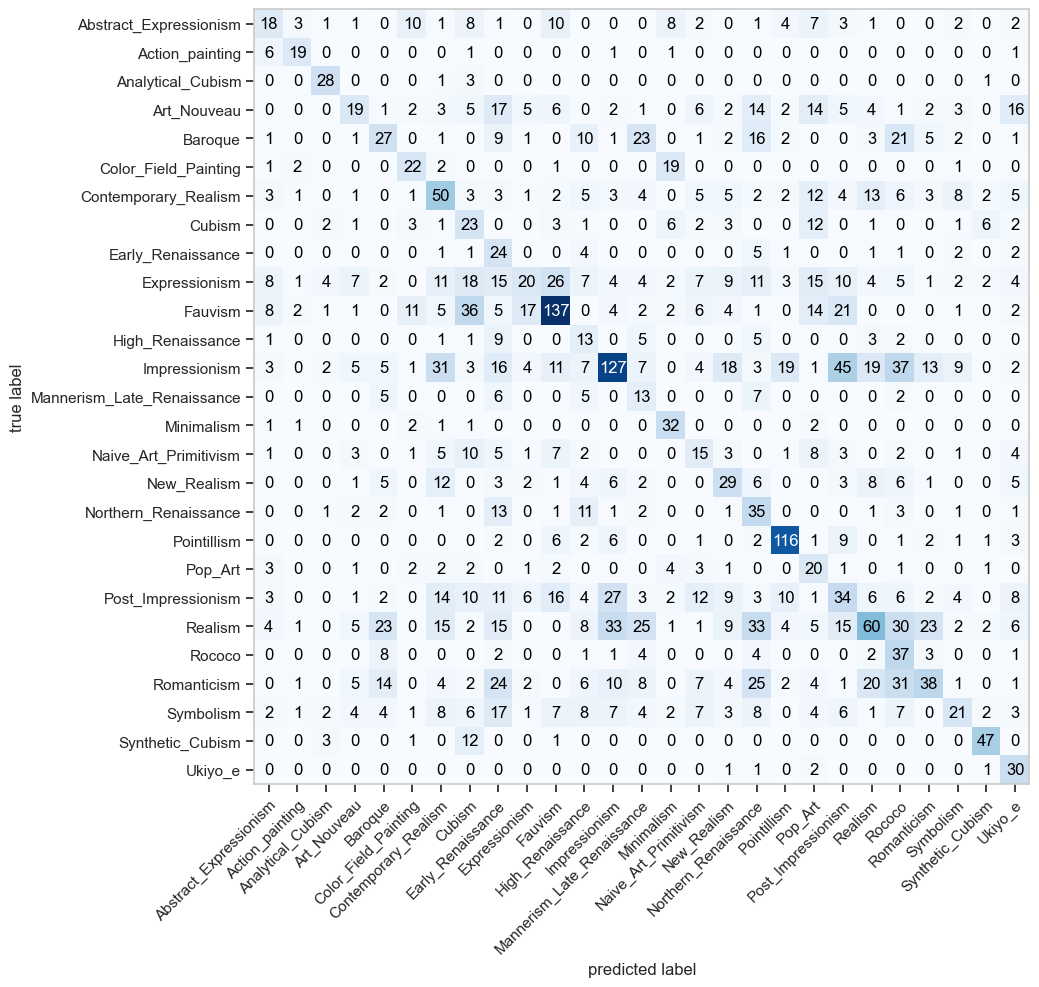


Classification Report:
                            precision    recall  f1-score   support

    Abstract_Expressionism       0.29      0.22      0.25        83
           Action_painting       0.59      0.66      0.62        29
         Analytical_Cubism       0.64      0.85      0.73        33
               Art_Nouveau       0.33      0.15      0.20       130
                   Baroque       0.28      0.21      0.24       127
      Color_Field_Painting       0.39      0.46      0.42        48
      Contemporary_Realism       0.29      0.35      0.32       144
                    Cubism       0.16      0.34      0.21        67
         Early_Renaissance       0.12      0.57      0.20        42
             Expressionism       0.33      0.10      0.15       202
                   Fauvism       0.58      0.49      0.53       280
          High_Renaissance       0.13      0.33      0.19        40
             Impressionism       0.55      0.32      0.41       392
Mannerism_Late_Renaissa

Train batch progress:   0%|          | 0/127 [00:00<?, ?it/s]

    Train Loss: 1.8270, Train Accuracy: 39.26%


Val batch progress:   0%|          | 0/50 [00:00<?, ?it/s]

    Val Loss: 1.9641, Val Accuracy: 37.37%

Confusion Matrix:


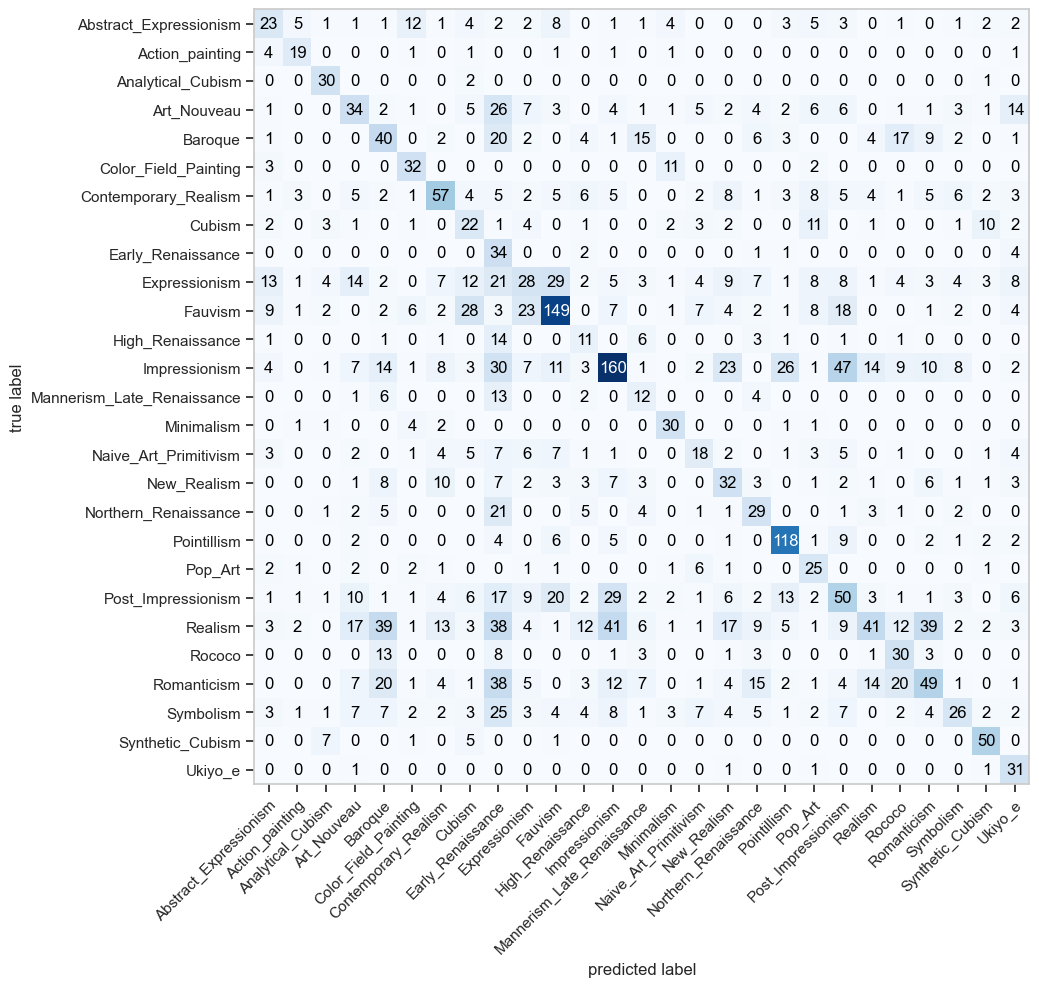


Classification Report:
                            precision    recall  f1-score   support

    Abstract_Expressionism       0.31      0.28      0.29        83
           Action_painting       0.54      0.66      0.59        29
         Analytical_Cubism       0.58      0.91      0.71        33
               Art_Nouveau       0.30      0.26      0.28       130
                   Baroque       0.25      0.31      0.28       127
      Color_Field_Painting       0.47      0.67      0.55        48
      Contemporary_Realism       0.48      0.40      0.44       144
                    Cubism       0.21      0.33      0.26        67
         Early_Renaissance       0.10      0.81      0.18        42
             Expressionism       0.27      0.14      0.18       202
                   Fauvism       0.60      0.53      0.56       280
          High_Renaissance       0.18      0.28      0.22        40
             Impressionism       0.56      0.41      0.47       392
Mannerism_Late_Renaissa

Train batch progress:   0%|          | 0/127 [00:00<?, ?it/s]

    Train Loss: 1.7051, Train Accuracy: 42.38%


Val batch progress:   0%|          | 0/50 [00:00<?, ?it/s]

    Val Loss: 1.9047, Val Accuracy: 39.33%

Confusion Matrix:


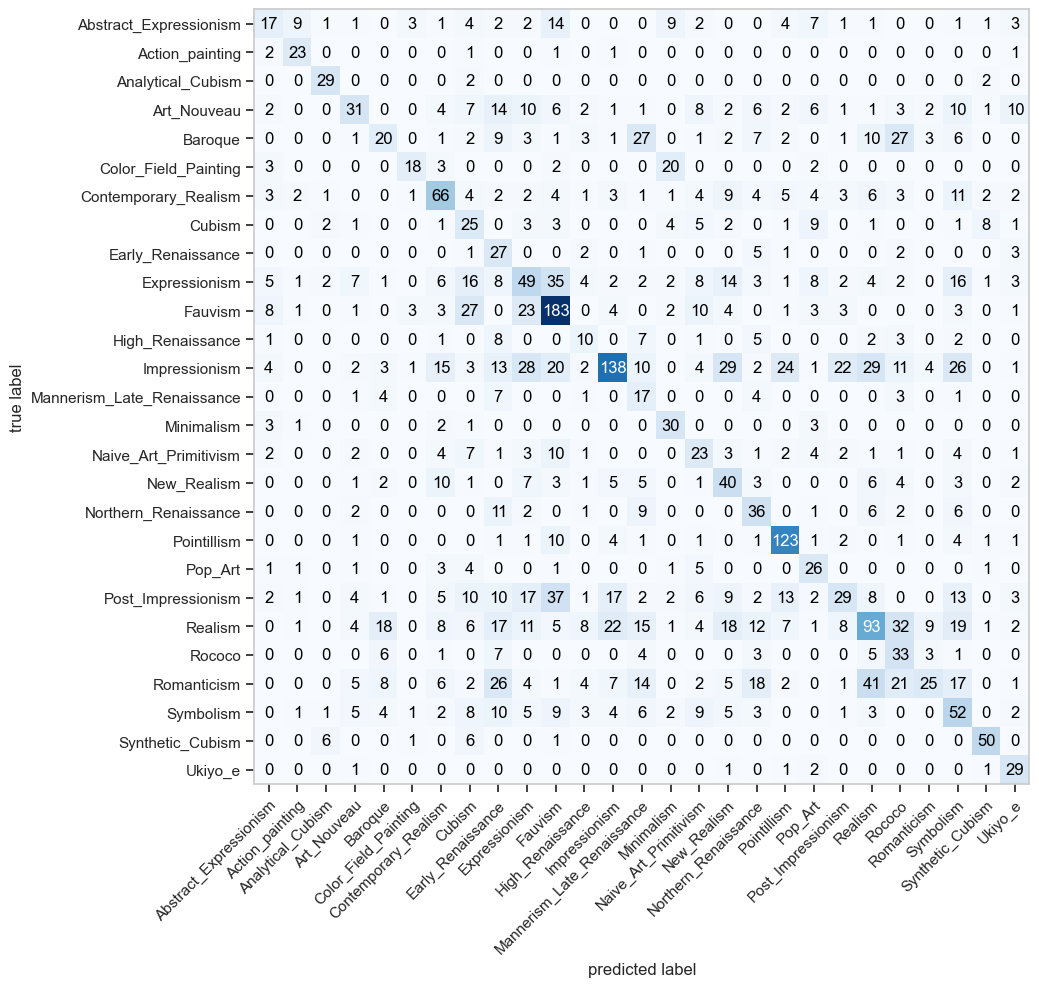


Classification Report:
                            precision    recall  f1-score   support

    Abstract_Expressionism       0.32      0.20      0.25        83
           Action_painting       0.56      0.79      0.66        29
         Analytical_Cubism       0.69      0.88      0.77        33
               Art_Nouveau       0.44      0.24      0.31       130
                   Baroque       0.30      0.16      0.21       127
      Color_Field_Painting       0.64      0.38      0.47        48
      Contemporary_Realism       0.46      0.46      0.46       144
                    Cubism       0.18      0.37      0.25        67
         Early_Renaissance       0.16      0.64      0.25        42
             Expressionism       0.29      0.24      0.26       202
                   Fauvism       0.53      0.65      0.58       280
          High_Renaissance       0.23      0.25      0.24        40
             Impressionism       0.66      0.35      0.46       392
Mannerism_Late_Renaissa

Train batch progress:   0%|          | 0/127 [00:00<?, ?it/s]

    Train Loss: 1.6154, Train Accuracy: 44.08%


Val batch progress:   0%|          | 0/50 [00:00<?, ?it/s]

    Val Loss: 1.9129, Val Accuracy: 37.87%

Confusion Matrix:


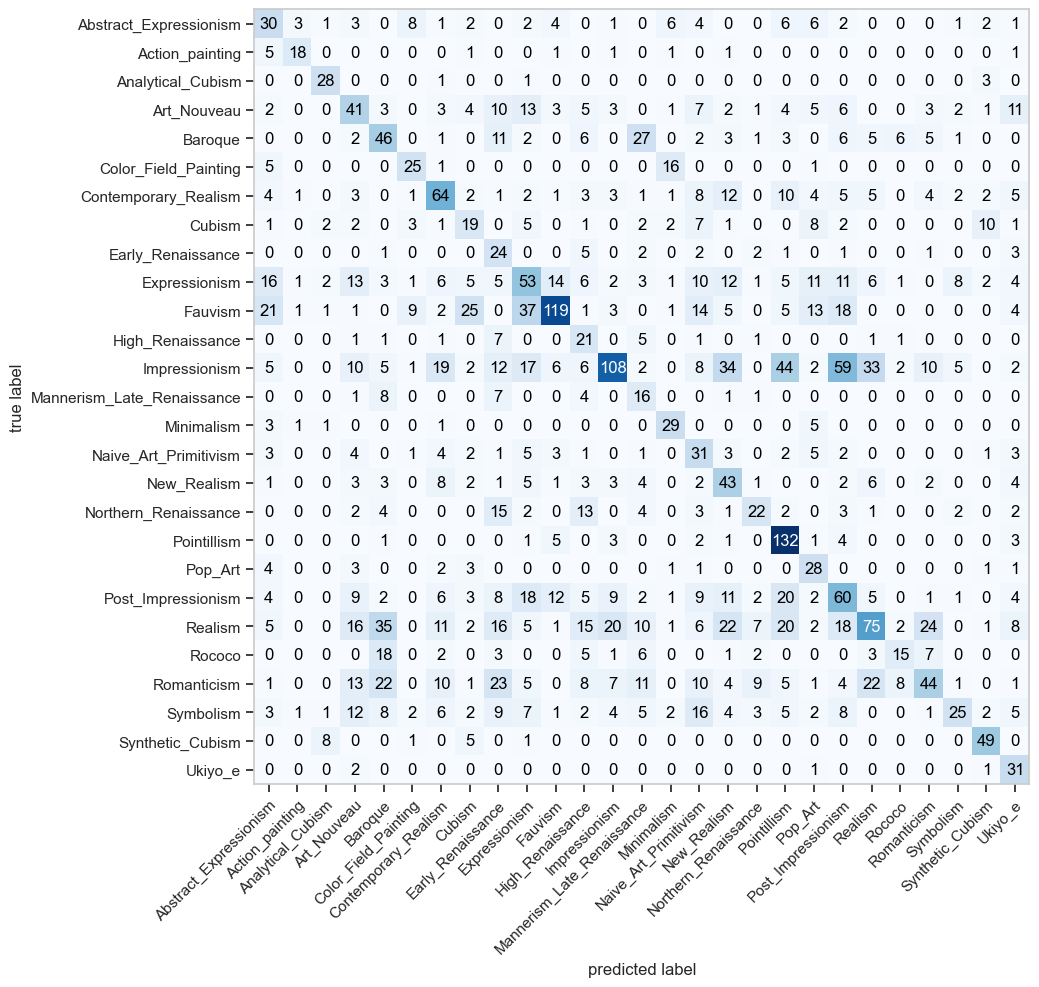


Classification Report:
                            precision    recall  f1-score   support

    Abstract_Expressionism       0.27      0.36      0.31        83
           Action_painting       0.69      0.62      0.65        29
         Analytical_Cubism       0.64      0.85      0.73        33
               Art_Nouveau       0.29      0.32      0.30       130
                   Baroque       0.29      0.36      0.32       127
      Color_Field_Painting       0.48      0.52      0.50        48
      Contemporary_Realism       0.43      0.44      0.44       144
                    Cubism       0.24      0.28      0.26        67
         Early_Renaissance       0.16      0.57      0.25        42
             Expressionism       0.29      0.26      0.28       202
                   Fauvism       0.70      0.42      0.53       280
          High_Renaissance       0.19      0.53      0.28        40
             Impressionism       0.64      0.28      0.39       392
Mannerism_Late_Renaissa

Train batch progress:   0%|          | 0/127 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [13]:
import pygame

# End of epoch alert
pygame.mixer.init()
audio_file = "C:/Users/valen.DESKTOP-4L65KSL/Downloads/death_stranding_like.mp3"
pygame.mixer.music.load(audio_file)


history = {}
print(config)
for epoch in range(counter_start, EPOCHS+counter_start):
    # timing utilities
    print(f"\n ----- Epoch {epoch}/{EPOCHS+counter_start-1} -----")
    start = torch.cuda.Event(enable_timing=True)
    start.record() 
    # train fn
    train_loss_rate, train_accuracy = train(train_loader, 
                                            loss, 
                                            opt, 
                                            model=chosen_model, 
                                            scaler=scaler, 
                                            lr_scheduler=scheduler, 
                                            device=device,
                                            reg=CUSTOM_REGULARIZATION)
    
    # validation function
    val_loss_rate, val_accuracy = validate(val_loader,
                                            unweighted_loss, 
                                            model=chosen_model,
                                            device=device,
                                            metrics=True,
                                            classes=val_dataset.classes)
    
    
    history[f"Epoch {epoch}"] = {"train": [round(train_loss_rate, 4), train_accuracy], "val": [round(val_loss_rate, 4), val_accuracy]}
    
    end = torch.cuda.Event(enable_timing=True) # stopping time  
    end.record()
    torch.cuda.synchronize()  # Waits for everything to finish running on the GPU
    recorded_time = start.elapsed_time(end)
    print(f"\nGPU time: {int(recorded_time // 60000)}m {int((recorded_time % 60000) // 1000)}s {round(recorded_time % 1000)}ms at local time {datetime.now().strftime('%H:%M:%S')}\n") 
    pygame.mixer.music.play()
    print(":"*200)

#### Saving model

In [ ]:
current_date = datetime.today().strftime("%m-%d-%y")
current_time = datetime.now().strftime('%H-%M')
path = f"models/Resnet50/wikiart_checkpoints_{current_date}"
if not os.path.exists(path):
  os.mkdir(path)
try:
    torch.save({
        'model_state_dict': chosen_model.state_dict(),
        'optimizer_state_dict': opt.state_dict(),
        'last_epoch': epoch,
        'lr_scheduler': scheduler.state_dict(),
        'scaler_state_dict': scaler.state_dict()
    }, 
    f=f"{path}/checkpoint{current_time}.pth")
except Exception as e:
    print(f"Checkpoint not saved due to {e}. Try changing dict parameters")


try:
    with open(f"{path}/config{current_time}.json", "w", encoding="utf-8") as config_json:
            json.dump(config, config_json)
    with open(f"{path}/history{current_time}.json", "w", encoding="utf-8") as history_json:
            json.dump(history, history_json)
except Exception as e:
    print(f"Failed to save config because {e}.")


In [ ]:
# torch.save(model_01, "models/wikiArt55.pth")

#### Prediction example

In [ ]:
# Get a single batch from the validation loader
chosen_model.eval()  # Set the model to evaluation mode
images, true_labels = next(iter(train_loader))

images = images.to(device)
true_labels = true_labels.to(device)

# Perform a forward pass to get predictions
with torch.inference_mode():
    outputs = chosen_model(images)
    probabilities = F.softmax(outputs, dim=1)

# Get the predicted label and confidence
predicted_labels = torch.argmax(outputs, 1)
confidence, _ = torch.max(probabilities, 1)

# Randomly select an index for the image to display
index = random.randint(0, images.size(0) - 1)
image = images[index].cpu().permute(1, 2, 0).numpy()  # Convert to HxWxC format for plotting
true_label = true_labels[index].item()
predicted_label = predicted_labels[index].item()
confidence_score = confidence[index].item()

# Convert the label indexes back to string labels using the dataset's index_to_label dictionary
true_label_str = val_dataset.dec[true_label]
predicted_label_str = val_dataset.dec[predicted_label]

# Print the true label, predicted label, and confidence
print(f"True Label: {true_label_str}")
print(f"Predicted Label: {predicted_label_str}")
print(f"Model Confidence: {confidence_score:.4f}")

# Optionally, display the image
plt.imshow(image)
plt.title(f"True: {true_label_str}, Predicted: {predicted_label_str}, Confidence: {confidence_score:.4f}")
plt.axis('off')
plt.show()